In [1]:
import os 
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import scgen
import seaborn as sns
from scipy import stats
import sklearn as sk
import matplotlib
from scgen.file_utils import ensure_dir
matplotlib.rc('ytick', labelsize=14)
matplotlib.rc('xtick', labelsize=14)
sc.set_figure_params(dpi_save=300)

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2026-02-16 00:27:58.353260: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 00:27:58.457242: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH:

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
path_to_save = "../results/Figures/Supplemental Figure 11/"
ensure_dir(path_to_save)
sc.settings.figdir = path_to_save

In [3]:
data = scgen.load_file("../data/MouseAtlas.subset.h5ad")
data

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 114600 × 2797
    obs: 'Organ', 'n_genes', 'n_counts', 'sample', 'louvain', 'summary2', 'batch', 'organ_sample', 'cnk', 'smp_org', 'chk', 'summary1', 'Organ groups', 'organ groups', 'cell types', 'Dataset', 'Cell types', 'Hox_genes'
    var: 'GeneName', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Cell types_colors', 'Dataset_colors', 'Organ groups_colors', 'cell types_colors', 'idx', 'louvain', 'louvain_colors', 'neighbors', 'organ groups_colors', 'pca', 'rank_genes_groups', 'sample_color', 'sample_colors', 'summary1_colors', 'summary2_colors'
    obsm: 'X_pca', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [4]:
data.obs.groupby(['cell types']).size()

/tmp/ipykernel_70511/894720111.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.obs.groupby(['cell types']).size()


cell types
B cell                            6423
Embryonic/Fetal/Neonatal cell    19188
Endothelial                       7457
Epithelial                       25228
Erythrocyte                       4850
Hematopoietic stem cell           2880
Megakaryocyte                     6125
Mesenchymal cell                 10878
Muscle                            1050
Myeloid cell                     11572
NK cell                            835
Neuron/glial cell                 6156
Smooth muscle                     1369
T cell                           10589
dtype: int64

In [5]:
data.obs.groupby(['Dataset']).size()

/tmp/ipykernel_70511/4280591384.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.obs.groupby(['Dataset']).size()


Dataset
Brain               1005
Embryo               287
Gastrula             456
HSC                 2845
Kidney              3705
MCA                58809
Tabula(Droplet)    18268
Tabula(Plate)      27023
Thymus              2202
dtype: int64

In [6]:
data.obs.groupby(['Organ groups']).size()

/tmp/ipykernel_70511/2077360107.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.obs.groupby(['Organ groups']).size()


Organ groups
Digestive system       11082
Embryo/Stem cells       5859
Endocrine system        9091
Fetal                  16446
Immune system          22320
Muscular system         7893
Neonatal                8585
Nervous system          5175
Others                  2951
Reproductive system     4496
Respiratory system      6525
Skin                    2471
Urinal system          11706
dtype: int64

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

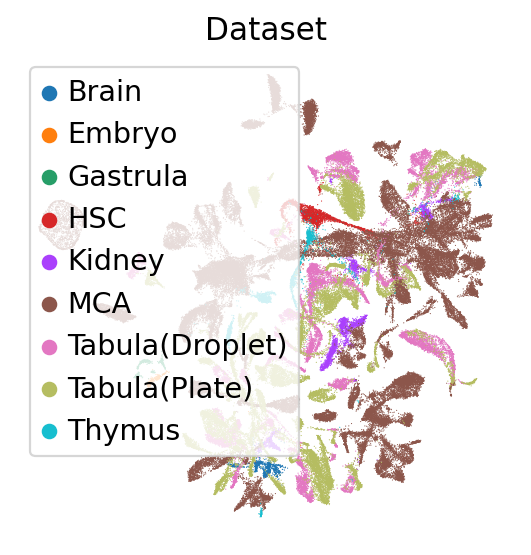

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

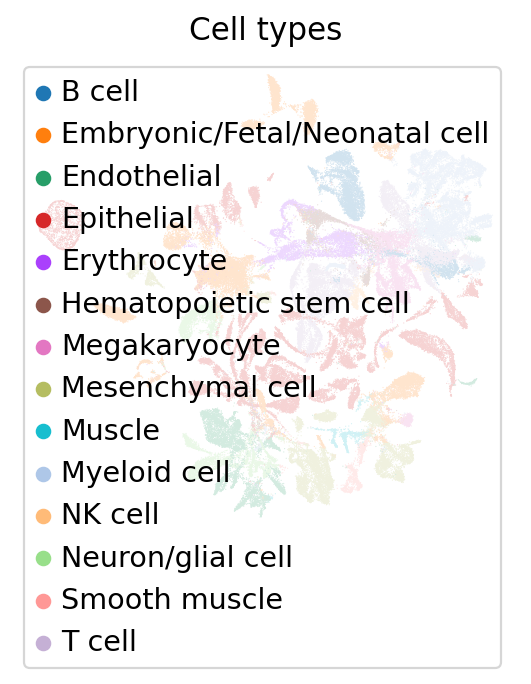

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

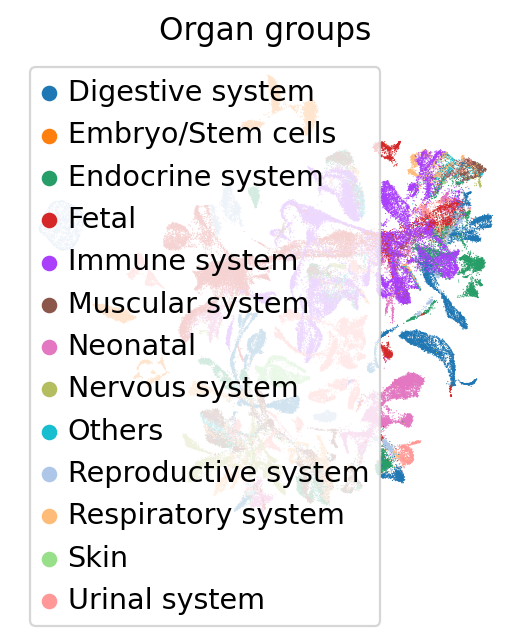

In [7]:
sc.pp.pca(data, svd_solver="arpack")
sc.pp.neighbors(data, n_neighbors=25)
sc.tl.umap(data)
sc.pl.umap(data, legend_loc=False, palette=matplotlib.rcParams["axes.prop_cycle"], color=['Dataset'], save="orig_mouse_datasets.png", frameon=False, show=False)
sc.pl.umap(data, legend_loc=False, palette=matplotlib.rcParams["axes.prop_cycle"], color=['Cell types'], save="orig_mouse_Cell types.png", frameon=False, show=False)
sc.pl.umap(data, legend_loc=False, palette=matplotlib.rcParams["axes.prop_cycle"], color=['Organ groups'], save="orig_mouse_Organ groups.png", frameon=False, show=False)

sc.pl.umap(data, legend_loc=False, palette=matplotlib.rcParams["axes.prop_cycle"], color=['Dataset'], save="orig_mouse_datasets.pdf", frameon=False, show=True)
sc.pl.umap(data, legend_loc=False, palette=matplotlib.rcParams["axes.prop_cycle"], color=['Cell types'], save="orig_mouse_Cell types.pdf", frameon=False, show=True)
sc.pl.umap(data, legend_loc=False, palette=matplotlib.rcParams["axes.prop_cycle"], color=['Organ groups'], save="orig_mouse_Organ groups.pdf", frameon=False, show=True)

In [8]:
X_pca = data.obsm["X_pca"]
labels = data.obs["Dataset"].tolist()
print(f"average silhouette_score for original mouse :{sk.metrics.silhouette_score(X_pca,labels,sample_size=57300, random_state=2)}")

average silhouette_score for original mouse :-0.2386959046125412


In [9]:
%%bash
python ../code/mouse_atlas.py

2026-02-16 00:32:03.911484: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 00:32:04.014448: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-02-16 00:32:04.014493: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-02-16 00:32:04.035452: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026

Reconstruction output already exists, skipping: ../data/reconstructed/scGen/mouse_atlas.h5ad


In [10]:
corrected_mouse_atlas = scgen.load_file("../data/reconstructed/scGen/mouse_atlas.h5ad")
corrected_mouse_atlas

AnnData object with n_obs × n_vars = 114600 × 2797
    obs: 'cell_type', 'Dataset', 'Organ groups'

In [11]:
corrected_mouse_atlas.obs.groupby(['cell_type']).size()

/tmp/ipykernel_70511/3793778078.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corrected_mouse_atlas.obs.groupby(['cell_type']).size()


cell_type
B cell                            6423
Embryonic/Fetal/Neonatal cell    19188
Endothelial                       7457
Epithelial                       25228
Erythrocyte                       4850
Hematopoietic stem cell           2880
Megakaryocyte                     6125
Mesenchymal cell                 10878
Muscle                            1050
Myeloid cell                     11572
NK cell                            835
Neuron/glial cell                 6156
Smooth muscle                     1369
T cell                           10589
dtype: int64

In [12]:
corrected_mouse_atlas.obs.groupby(['Dataset']).size()

/tmp/ipykernel_70511/2769223045.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corrected_mouse_atlas.obs.groupby(['Dataset']).size()


Dataset
Brain               1005
Embryo               287
Gastrula             456
HSC                 2845
Kidney              3705
MCA                58809
Tabula(Droplet)    18268
Tabula(Plate)      27023
Thymus              2202
dtype: int64

In [13]:
corrected_mouse_atlas.obs.groupby(['Organ groups']).size()

/tmp/ipykernel_70511/304984429.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corrected_mouse_atlas.obs.groupby(['Organ groups']).size()


Organ groups
Digestive system       11082
Embryo/Stem cells       5859
Endocrine system        9091
Fetal                  16446
Immune system          22320
Muscular system         7893
Neonatal                8585
Nervous system          5175
Others                  2951
Reproductive system     4496
Respiratory system      6525
Skin                    2471
Urinal system          11706
dtype: int64

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

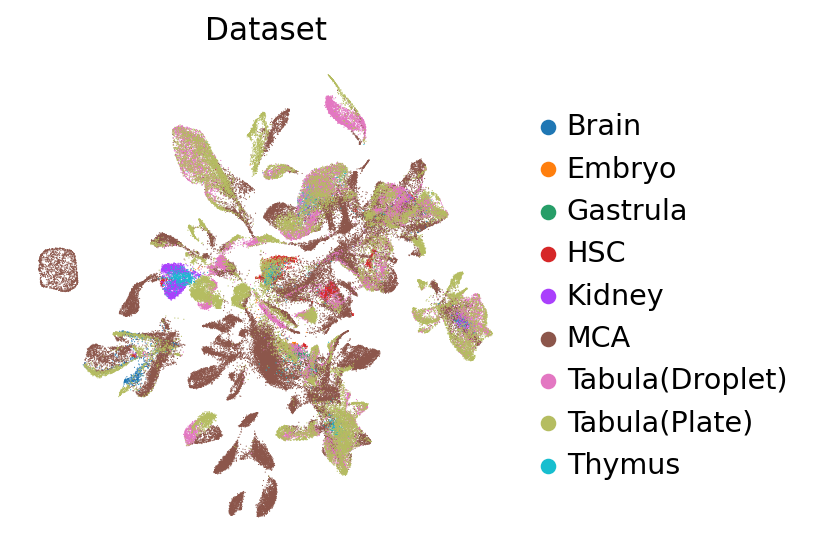

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

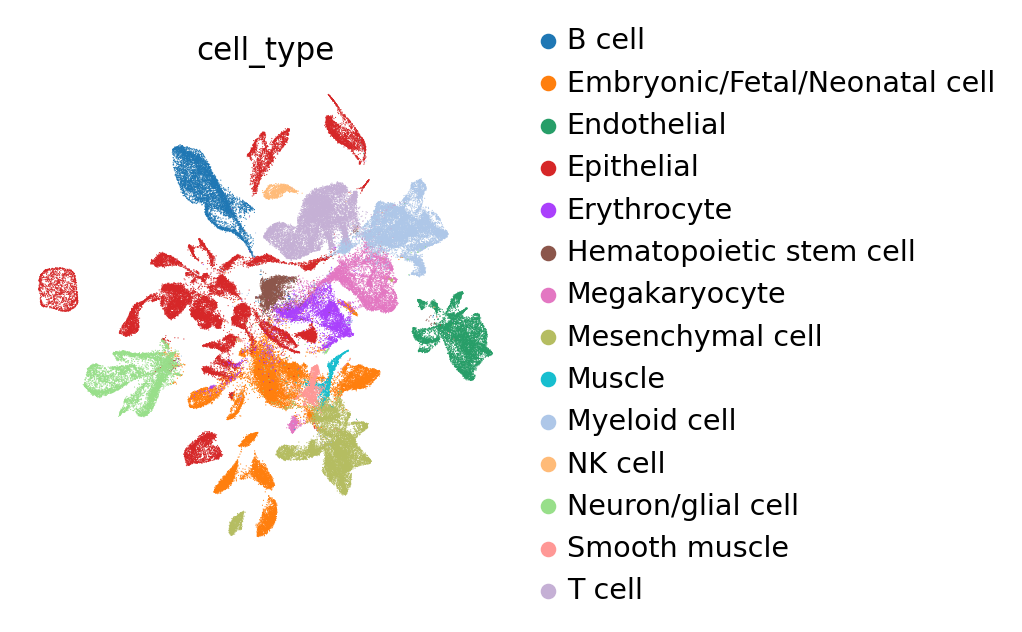

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

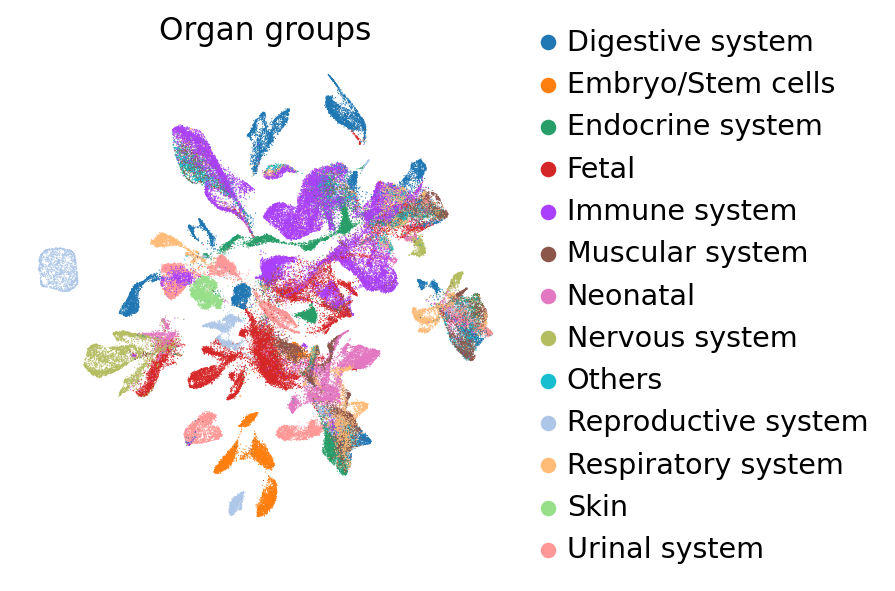

In [14]:
sc.pp.pca(corrected_mouse_atlas, svd_solver="arpack")
sc.pp.neighbors(corrected_mouse_atlas, n_neighbors=25)
sc.tl.umap(corrected_mouse_atlas)
sc.pl.umap(corrected_mouse_atlas, palette=matplotlib.rcParams["axes.prop_cycle"], color=['Dataset'], save="corrected_mouse_datasets_dsm.png",
           frameon=False, show=False)
sc.pl.umap(corrected_mouse_atlas, palette=matplotlib.rcParams["axes.prop_cycle"], color=['cell_type'], save="corrected_mouse_Cell types_dsm.png",
           frameon=False, show=False)
sc.pl.umap(corrected_mouse_atlas, palette=matplotlib.rcParams["axes.prop_cycle"], color=['Organ groups'], save="corrected_mouse_Organ groups_dsm.png",
           frameon=False, show=False)

sc.pl.umap(corrected_mouse_atlas, palette=matplotlib.rcParams["axes.prop_cycle"], color=['Dataset'], save="corrected_mouse_datasets_dsm.pdf",
           frameon=False, show=True)
sc.pl.umap(corrected_mouse_atlas, palette=matplotlib.rcParams["axes.prop_cycle"], color=['cell_type'], save="corrected_mouse_Cell types_dsm.pdf",
           frameon=False, show=True)
sc.pl.umap(corrected_mouse_atlas, palette=matplotlib.rcParams["axes.prop_cycle"], color=['Organ groups'], save="corrected_mouse_Organ groups_dsm.pdf",
           frameon=False, show=True)

In [15]:
X_pca = corrected_mouse_atlas.obsm["X_pca"]
labels2 = corrected_mouse_atlas.obs["Dataset"].tolist()
print(f"average silhouette_score for scGen :{sk.metrics.silhouette_score(X_pca,labels2,sample_size=57300, random_state=2)}")

average silhouette_score for scGen :-0.24536848068237305
